In [ ]:
#Random Forest with Hyperparameter Tuning
#Import libraries
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [ ]:
#Load Data
X_train = pd.read_csv("../data/model_input/X_train.csv")
X_test = pd.read_csv("../data/model_input/X_test.csv")

y_train = pd.read_csv("../data/model_input/y_train.csv").squeeze()
y_test = pd.read_csv("../data/model_input/y_test.csv").squeeze()

In [3]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2400, 38)
(600, 38)
(2400,)
(600,)


In [ ]:
#Creating the base Random Forest model
rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [ ]:
#Define the parameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [ ]:
#Configure GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

In [ ]:
#The tuning
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_pa

In [ ]:
#The best parameters
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation F1 Score:
0.8775370065417274


In [ ]:
#The best model
best_rf_model = grid_search.best_estimator_

In [ ]:
#Checking the training and testing accuracy
train_accuracy = best_rf_model.score(X_train, y_train)
test_accuracy = best_rf_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9570833333333333
Testing Accuracy: 0.8516666666666667


In [ ]:
#Making predictions
y_pred = best_rf_model.predict(X_test)

In [ ]:
#Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8516666666666667
Precision: 0.8557125124959392
Recall   : 0.8516666666666667
F1 Score : 0.8530445069237315


In [ ]:
#Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.88      0.87      0.88       200
         Low       0.93      0.87      0.90       202
      Medium       0.76      0.81      0.78       198

    accuracy                           0.85       600
   macro avg       0.86      0.85      0.85       600
weighted avg       0.86      0.85      0.85       600



In [14]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[174   0  26]
 [  0 176  26]
 [ 23  14 161]]


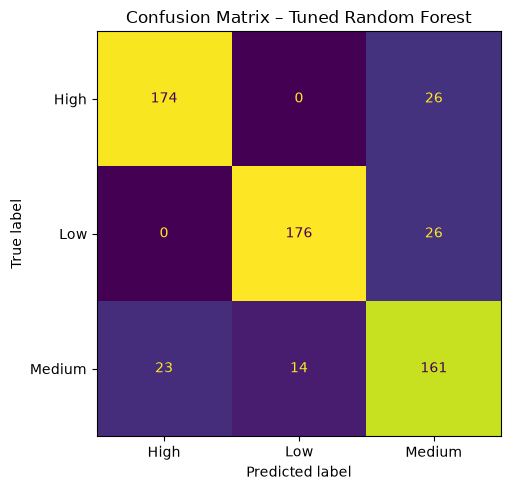

In [15]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=best_rf_model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_rf_model.classes_
)

fig, ax = plt.subplots(figsize=(6, 5))

disp.plot(
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix – Tuned Random Forest")
plt.tight_layout()
plt.show()

In [ ]:
#Feature importance table
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
7,bacteria_count,0.226341
1,contaminant_level,0.158173
3,turbidity,0.152804
6,lead,0.087690
5,nitrate,0.061157
4,dissolved_oxygen,0.051809
9,infant_mortality_rate,0.038857
8,clean_water_access,0.031264
10,gdp_per_capita,0.029699
13,sanitation_coverage,0.029153


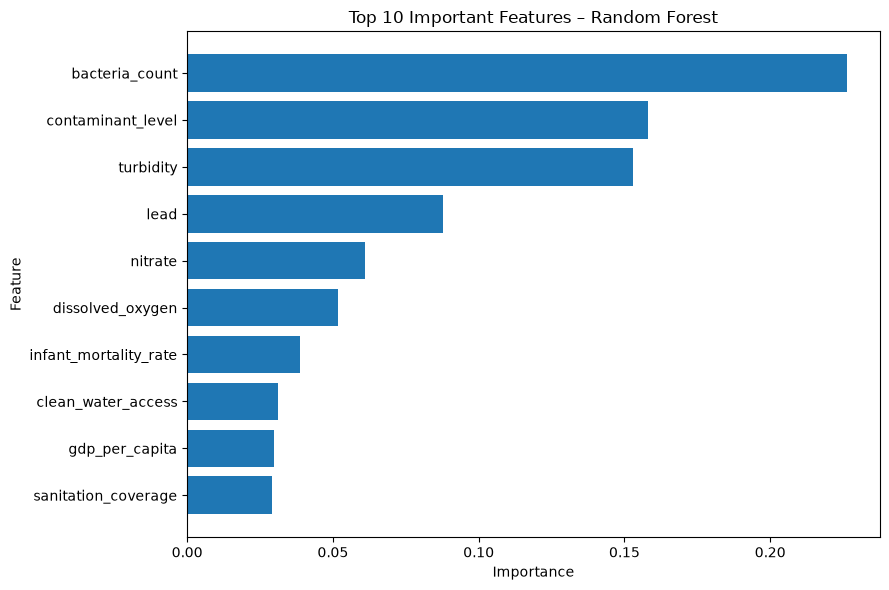

In [ ]:
#Plot for the top 10 features
top_features = feature_importance.head(10)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Important Features – Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
#The results table
results_rf = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Accuracy",
        "Cross-Validation F1"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        train_accuracy,
        grid_search.best_score_
    ]
})

results_rf

,Metric,Value
0,Accuracy,0.851667
1,Precision,0.855713
2,Recall,0.851667
3,F1 Score,0.853045
4,Training Accuracy,0.957083
5,Cross-Validation F1,0.877537


In [ ]:
#Model saving
joblib.dump(
    best_rf_model,
    "../models/random_forest_tuned.pkl"
)

['../models/random_forest_tuned.pkl']

In [ ]:
#Save the encoded feature names
joblib.dump(
    X_train.columns.tolist(),
    "../models/model_feature_names.pkl"
)

['../models/model_feature_names.pkl']

In [ ]:
#Saving the tuning results
cv_results = pd.DataFrame(grid_search.cv_results_)

cv_results.to_csv(
    "../reports/tables/random_forest_grid_search_results.csv",
    index=False
)